# 02 Objective Windows
Explore the objective-window table: outcome distributions, setup profiles, feature correlations with securing the objective.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from lolobj.config import PROCESSED_DIR

parquet_path = PROCESSED_DIR / 'objective_windows.parquet'
df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df)} rows, {df["match_id"].nunique()} matches')
df.head(3)

Loaded 68248 rows, 3834 matches


,match_id,objective_instance,objective_type,objective_number,objective_time_ms,team_id,team_side,rank_bucket,patch,monster_subtype,...,adc_unspent_gold_T_60,mid_unspent_gold_T_30,mid_unspent_gold_T_60,top_unspent_gold_T_30,top_unspent_gold_T_60,team_unspent_gold_T_30,team_unspent_gold_T_60,secured,outcome_label,net_value
0,EUW1_7108550527,voidgrub_1,HORDE,1,401903,100,blue,low,14.17.615.2328,,...,74,678,175,712.0,533.0,2568,1476,1,no_meaningful_contest,7
1,EUW1_7108550527,voidgrub_1,HORDE,1,401903,200,red,low,14.17.615.2328,,...,952,496,268,1148.0,791.0,2575,2087,0,no_meaningful_contest,-1
2,EUW1_7108550527,voidgrub_2,HORDE,2,408315,100,blue,low,14.17.615.2328,,...,74,678,175,712.0,533.0,2568,1476,1,no_meaningful_contest,3


## Feature filtering — temporal redundancy analysis

Run this before any other analysis. It drops features that have near-zero signal or are near-duplicates of a better sibling, and defines `FEATURES_KEEP` used by all subsequent feature-based cells.

**Drop criteria:**
- `|corr| < 0.05` with `secured` — essentially no signal
- inter-corr > 0.85 with a sibling that has stronger target correlation — redundant

In [ ]:
_CANDIDATE_FEATURES = [
    # Arrival / presence
    'arrived_first',
    'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30',
    'enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30',
    # Alive counts
    'team_alive_T_30', 'team_alive_T_60',
    'enemy_alive_T_30', 'enemy_alive_T_60',
    'jungler_alive_T_30', 'jungler_alive_T_60',
    'support_alive_T_30', 'support_alive_T_60',
    # Deaths
    'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s',
    'enemy_deaths_30s', 'enemy_deaths_60s',
    # Gold / combat power
    'gold_diff_T_30', 'gold_diff_T_60',
    'jungler_level_diff_T_30', 'jungler_level_diff_T_60',
    # Vision
    'wards_placed_120s', 'wards_killed_120s',
    # Prior context
    'previous_same_obj_team', 'previous_same_obj_enemy',
    # Unspent gold
    'team_unspent_gold_T_30', 'team_unspent_gold_T_60',
    'jungler_unspent_gold_T_30', 'support_unspent_gold_T_30',
    'adc_unspent_gold_T_30', 'mid_unspent_gold_T_30', 'top_unspent_gold_T_30',
]
_CANDIDATE_FEATURES = [c for c in _CANDIDATE_FEATURES if c in df.columns]

target_corr = df[_CANDIDATE_FEATURES + ['secured']].corr()['secured'].drop('secured')

# Step 1: drop weak signal (|corr| < 0.05)
WEAK_SIGNAL_THRESHOLD = 0.05
weak_drop = {c for c, v in target_corr.items() if abs(v) < WEAK_SIGNAL_THRESHOLD}

# Step 2: drop redundant sibling (inter-corr > 0.85, weaker target corr)
REDUNDANT_THRESHOLD = 0.85
_families = {
    'team_nearby':       ['team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30'],
    'enemy_nearby':      ['enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30'],
    'team_alive':        ['team_alive_T_60', 'team_alive_T_30'],
    'enemy_alive':       ['enemy_alive_T_60', 'enemy_alive_T_30'],
    'jungler_alive':     ['jungler_alive_T_60', 'jungler_alive_T_30'],
    'support_alive':     ['support_alive_T_60', 'support_alive_T_30'],
    'team_deaths':       ['team_deaths_90s', 'team_deaths_60s', 'team_deaths_30s'],
    'enemy_deaths':      ['enemy_deaths_60s', 'enemy_deaths_30s'],
    'gold_diff':         ['gold_diff_T_60', 'gold_diff_T_30'],
    'jg_level_diff':     ['jungler_level_diff_T_60', 'jungler_level_diff_T_30'],
    'team_unspent_gold': ['team_unspent_gold_T_60', 'team_unspent_gold_T_30'],
}
redundant_drop = set()
for cols in _families.values():
    valid = [c for c in cols if c in df.columns]
    for i, c1 in enumerate(valid):
        for c2 in valid[i+1:]:
            ic = df[[c1, c2]].corr().iloc[0, 1]
            if ic > REDUNDANT_THRESHOLD:
                weaker = c1 if abs(target_corr[c1]) < abs(target_corr[c2]) else c2
                redundant_drop.add(weaker)

all_drop = weak_drop | redundant_drop
FEATURES_KEEP = [c for c in _CANDIDATE_FEATURES if c not in all_drop]

# Report
print(f"Candidates : {len(_CANDIDATE_FEATURES)}")
print(f"Dropped (weak signal |corr| < {WEAK_SIGNAL_THRESHOLD}): {sorted(weak_drop)}")
print(f"Dropped (redundant inter-corr > {REDUNDANT_THRESHOLD}): {sorted(redundant_drop)}")
print(f"\nFEATURES_KEEP ({len(FEATURES_KEEP)} features):")
for c in sorted(FEATURES_KEEP, key=lambda x: -abs(target_corr[x])):
    print(f"  {c:<42}  corr={target_corr[c]:+.4f}")

## Outcome label definitions

Each row is one team's perspective on a single dragon spawn. The label describes how that team's interaction with the objective played out.

| Label | Meaning |
|---|---|
| **clean_take** | Secured without meaningful resistance — team arrived with numbers advantage, enemy barely present |
| **clean_give** | Team wasn't present at all; enemy took it freely |
| **good_trade** | Team gave the objective but gained something elsewhere (tower, kills, camps on the other side) |
| **coinflip** | Both teams showed up roughly even; whoever secured it won a fair contest |
| **bad_contest** | Team contested but was in a clearly losing state — outnumbered or down key members |
| **won_fight_lost_objective** | Team won the nearby fight (more kills) but enemy still secured the objective (smite steal, disengaged) |
| **lost_fight_got_objective** | Team lost the nearby fight (more deaths) but secured the objective anyway |
| **throw_setup** | Team had a playable setup but lost a key member (jungler or support) just before the objective |
| **objective_steal** | Team was clearly outnumbered but secured it anyway |
| **no_meaningful_contest** | Neither team was present — objective taken uncontested with no real fight |

Two rows are emitted per objective instance (one per team), so the two rows for the same dragon will have complementary but different labels.

## 1. Outcome label distribution

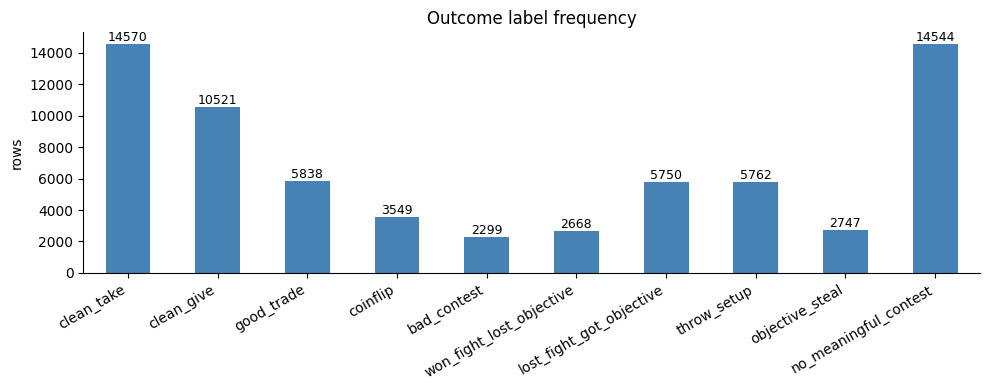

outcome_label
clean_take                  14570
clean_give                  10521
good_trade                   5838
coinflip                     3549
bad_contest                  2299
won_fight_lost_objective     2668
lost_fight_got_objective     5750
throw_setup                  5762
objective_steal              2747
no_meaningful_contest       14544


In [2]:
OUTCOME_ORDER = [
    'clean_take', 'clean_give', 'good_trade', 'coinflip',
    'bad_contest', 'won_fight_lost_objective', 'lost_fight_got_objective',
    'throw_setup', 'objective_steal', 'no_meaningful_contest',
]

counts = df['outcome_label'].value_counts().reindex(OUTCOME_ORDER).dropna()
ax = counts.plot(kind='bar', color='steelblue')
ax.set_title('Outcome label frequency')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(counts.to_string())

## 2. Setup profiles

Profiles are **relative** — they compare this team's state to the opponent's at T-30s.

| Profile | Condition | Expected secure rate |
|---|---|---|
| **both_absent** | Neither team nearby at T-30 | ~50% (coin flip) |
| **gave_away** | We weren't nearby; enemy was | ~15% |
| **free_setup** | We were nearby; enemy wasn't; no pre-obj deaths | ~90% |
| **free_setup_deaths** | We were nearby; enemy wasn't; had pre-obj deaths | ~80% |
| **clean_contest** | Both nearby; we have no deaths AND equal/more alive | ~70% |
| **disadvantaged** | Both nearby; we had deaths OR fewer alive than enemy | ~40% |

Rules are exclusive and exhaustive — every row gets exactly one label.

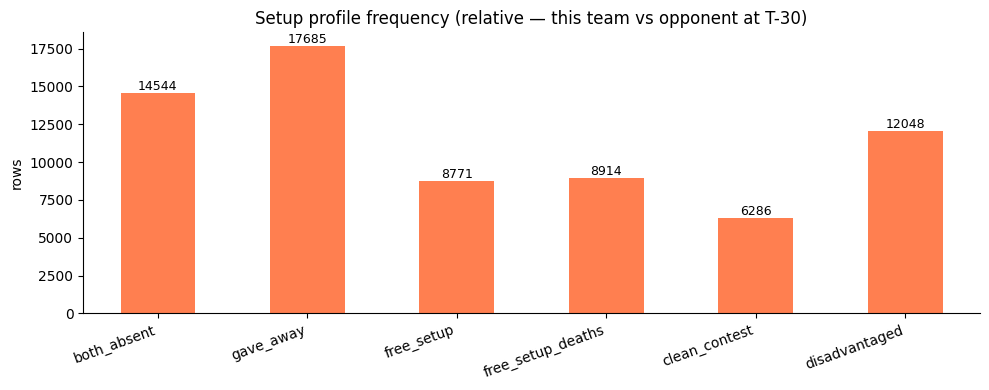

In [3]:
from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER

df['setup_profile'] = assign_setup_profiles(df)

pcounts = df['setup_profile'].value_counts().reindex(PROFILE_ORDER).dropna()

ax = pcounts.plot(kind='bar', color='coral')
ax.set_title('Setup profile frequency (relative — this team vs opponent at T-30)')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Secure rate by setup profile

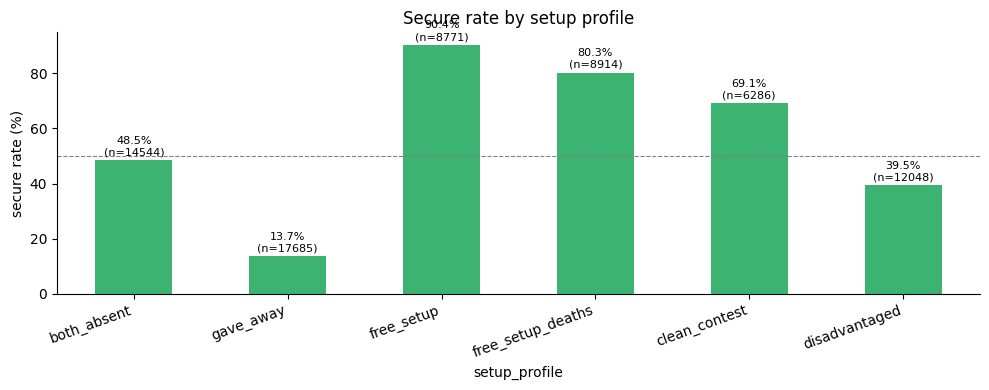

In [4]:
secure_by_profile = (
    df.groupby('setup_profile')['secured']
    .agg(['mean', 'count'])
    .reindex(PROFILE_ORDER)
    .dropna()
    .rename(columns={'mean': 'secure_rate', 'count': 'n'})
)
secure_by_profile['secure_rate_pct'] = (secure_by_profile['secure_rate'] * 100).round(1)

ax = secure_by_profile['secure_rate_pct'].plot(kind='bar', color='mediumseagreen')
ax.set_title('Secure rate by setup profile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=20, ha='right')
for i, (rate, n) in enumerate(zip(secure_by_profile['secure_rate_pct'], secure_by_profile['n'])):
    ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 3b. Sanity checks — do profiles and outcomes agree?

If the labeling logic is working correctly we should see:
- **free_setup** rows → mostly `clean_take` outcome (high secure rate, near-zero bad_contest)
- **gave_away** rows → mostly `clean_give` or `no_meaningful_contest` (near-zero secure rate)
- **disadvantaged** rows → higher `bad_contest`, `throw_setup`, and `lost_fight_got_objective` rates
- **clean_contest** rows → mixed but centered around 50% (fair fight)
- No outcome leakage: profiles are computed from pre-T features only

Flags to watch: if `free_setup` rows have a low secure rate, or `gave_away` rows somehow frequently secure, something is wrong in feature computation or labeling.

In [5]:
if 'setup_profile' not in df.columns:
    from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER
    df['setup_profile'] = assign_setup_profiles(df)

# Cross-tab: setup_profile x outcome_label (% within each profile)
ct = pd.crosstab(df['setup_profile'], df['outcome_label'], normalize='index') * 100
ct = ct.reindex(index=PROFILE_ORDER, columns=OUTCOME_ORDER).fillna(0).round(1)

print("Outcome distribution within each setup profile (% of rows in that profile):")
print(ct.to_string())

# Secure rate per profile
print("\nSecure rate per profile:")
sr = df.groupby('setup_profile')['secured'].agg(['mean', 'count'])
sr['mean'] = (sr['mean'] * 100).round(1)
print(sr.reindex(PROFILE_ORDER).dropna().rename(columns={'mean': 'secure_%', 'count': 'n'}).to_string())

# Sanity flags
print("\n--- SANITY FLAGS ---")
free_setup_sr  = df[df['setup_profile'] == 'free_setup']['secured'].mean()
gave_away_sr   = df[df['setup_profile'] == 'gave_away']['secured'].mean()
disadv_sr      = df[df['setup_profile'] == 'disadvantaged']['secured'].mean()
contest_sr     = df[df['setup_profile'] == 'clean_contest']['secured'].mean()

print(f"free_setup secure rate    : {free_setup_sr:.1%}  (expect > 85%)")
print(f"gave_away secure rate     : {gave_away_sr:.1%}  (expect < 15%)")
print(f"disadvantaged secure rate : {disadv_sr:.1%}  (expect < 40%)")
print(f"clean_contest secure rate : {contest_sr:.1%}  (expect 55–70%)")

Outcome distribution within each setup profile (% of rows in that profile):
outcome_label      clean_take  clean_give  good_trade  coinflip  bad_contest  won_fight_lost_objective  lost_fight_got_objective  throw_setup  objective_steal  no_meaningful_contest
setup_profile                                                                                                                                                                        
both_absent               0.0         0.0         0.0       0.0          0.0                       0.0                       0.0          0.0              0.0                  100.0
gave_away                 0.0        59.5        26.8       0.0          0.0                       0.0                       0.0          0.0             13.7                    0.0
free_setup               75.7         0.0         1.8       0.0          4.0                       3.9                      14.7          0.0              0.0                    0.0
free_setup_dea

## 3c. Setup matchup results — valid profile pairings

Because profiles are **relative** (this team vs opponent at T-30), most pairings are structurally impossible: if we're classified as `free_setup` (only we're present), the opponent is necessarily `gave_away` (they're absent). The full 6×6 matrix is therefore mostly empty by construction.

The table below shows only the **valid pairings** that can actually co-occur, and the secure rate for the team with "my_profile".

Valid matchup pairings (n >= 20):
       my_profile       opp_profile  secure_pct  count
        gave_away        free_setup         9.0   8771
        gave_away free_setup_deaths        18.4   8914
    disadvantaged     clean_contest        20.5   4184
      both_absent       both_absent        48.5  14544
    disadvantaged     disadvantaged        49.6   7864
    clean_contest     clean_contest        49.8   2102
    clean_contest     disadvantaged        78.8   4184
free_setup_deaths         gave_away        80.3   8914
       free_setup         gave_away        90.4   8771


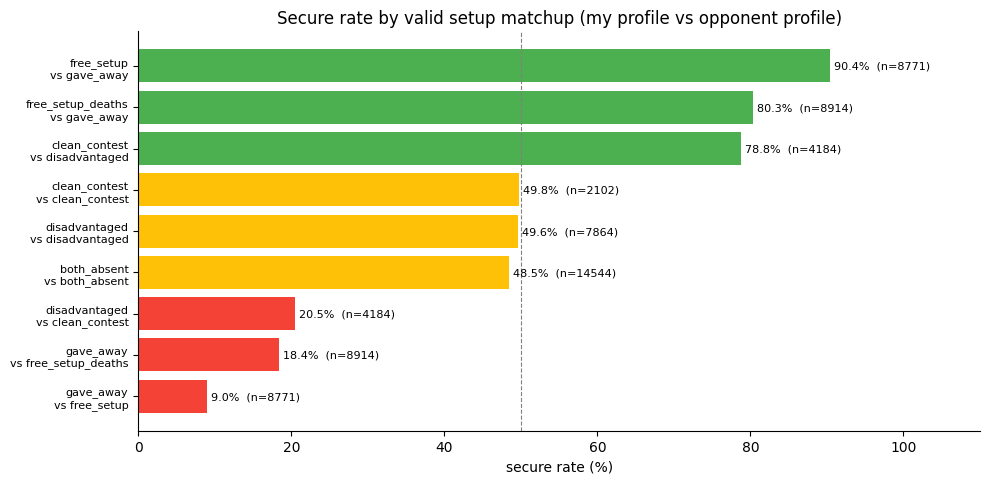

In [6]:
if 'setup_profile' not in df.columns:
    from lolobj.analysis.baseline_report import assign_setup_profiles, PROFILE_ORDER
    df['setup_profile'] = assign_setup_profiles(df)

# Join both teams per objective to get (my_profile, opp_profile) pairs
t100 = df[df['team_id'] == 100][['match_id', 'objective_instance', 'setup_profile', 'secured']].copy()
t200 = df[df['team_id'] == 200][['match_id', 'objective_instance', 'setup_profile', 'secured']].copy()
wide = t100.merge(t200, on=['match_id', 'objective_instance'], suffixes=('_t100', '_t200'))

from_t100 = wide.rename(columns={'setup_profile_t100': 'my_profile',
                                   'setup_profile_t200': 'opp_profile',
                                   'secured_t100': 'secured'})[
    ['match_id', 'objective_instance', 'my_profile', 'opp_profile', 'secured']]
from_t200 = wide.rename(columns={'setup_profile_t200': 'my_profile',
                                   'setup_profile_t100': 'opp_profile',
                                   'secured_t200': 'secured'})[
    ['match_id', 'objective_instance', 'my_profile', 'opp_profile', 'secured']]
matchup = pd.concat([from_t100, from_t200], ignore_index=True)

# Only keep pairings with enough data
agg = matchup.groupby(['my_profile', 'opp_profile'])['secured'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 20].copy()
agg['secure_pct'] = (agg['mean'] * 100).round(1)
agg['matchup'] = agg['my_profile'] + '\nvs ' + agg['opp_profile']
agg = agg.sort_values('secure_pct', ascending=True)

print("Valid matchup pairings (n >= 20):")
print(agg[['my_profile', 'opp_profile', 'secure_pct', 'count']].to_string(index=False))

# Horizontal bar chart — colour by secure rate
fig, ax = plt.subplots(figsize=(10, max(4, len(agg) * 0.55)))
colors = ['#F44336' if v < 40 else '#FFC107' if v < 60 else '#4CAF50' for v in agg['secure_pct']]
bars = ax.barh(range(len(agg)), agg['secure_pct'], color=colors)
ax.set_yticks(range(len(agg)))
ax.set_yticklabels(agg['matchup'], fontsize=8)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('secure rate (%)')
ax.set_title('Secure rate by valid setup matchup (my profile vs opponent profile)')
for i, (val, n) in enumerate(zip(agg['secure_pct'], agg['count'])):
    ax.text(val + 0.5, i, f'{val:.1f}%  (n={n})', va='center', fontsize=8)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 4. Key binary feature secure rates

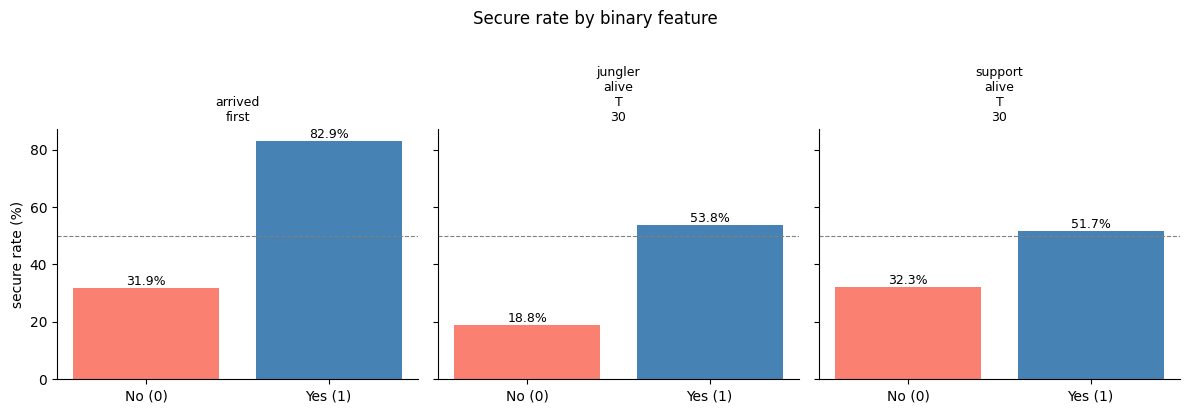

In [7]:
binary_features = [
    'arrived_first',
    'jungler_alive_T_30',
    'support_alive_T_30',
]

fig, axes = plt.subplots(1, len(binary_features), figsize=(12, 4), sharey=True)
for ax, feat in zip(axes, binary_features):
    rates = df.groupby(feat)['secured'].mean() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], [rates.get(0, 0), rates.get(1, 0)],
                   color=['salmon', 'steelblue'])
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('secure rate (%)' if ax == axes[0] else '')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, [rates.get(0, 0), rates.get(1, 0)]):
        ax.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, val + 1),
                    ha='center', fontsize=9)
plt.suptitle('Secure rate by binary feature', y=1.02)
plt.tight_layout()
plt.show()

## 5. Deaths before objective vs secure rate

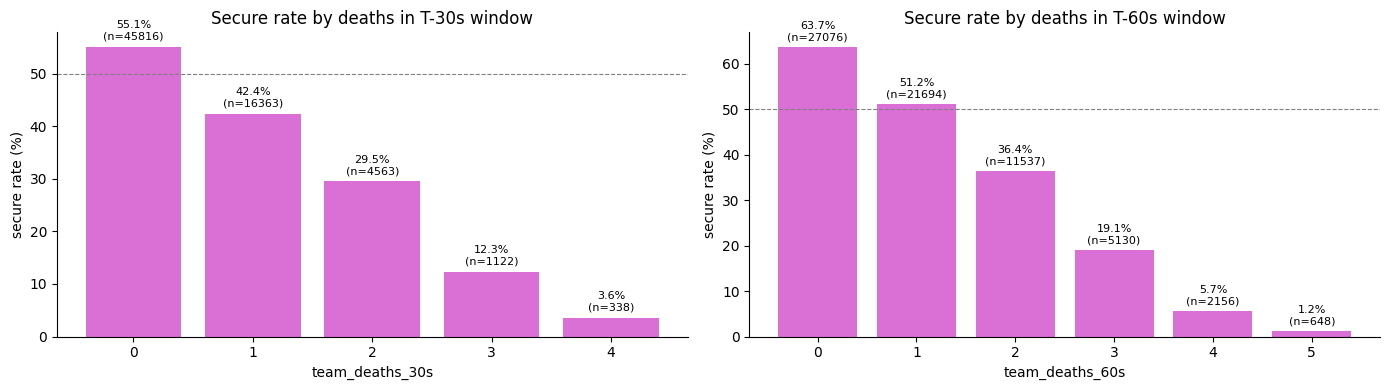


team_deaths_30s:
                 secure_%  count
team_deaths_30s                 
0                    55.1  45816
1                    42.4  16363
2                    29.5   4563
3                    12.3   1122
4                     3.6    338
5                     0.0     46

team_deaths_60s:
                 secure_%  count
team_deaths_60s                 
0                    63.7  27076
1                    51.2  21694
2                    36.4  11537
3                    19.1   5130
4                     5.7   2156
5                     1.2    648
6                     0.0      7

team_deaths_90s:
                 secure_%  count
team_deaths_90s                 
0                    65.9  16391
1                    56.8  20459
2                    46.3  15742
3                    32.6   8973
4                    19.0   4596
5                     7.8   1845
6                     7.3    219
7                     4.8     21
8                    50.0      2


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, col, title in [
    (axes[0], 'team_deaths_30s', 'deaths in T-30s window'),
    (axes[1], 'team_deaths_60s', 'deaths in T-60s window'),
]:
    death_secure = df.groupby(col)['secured'].agg(['mean', 'count'])
    death_secure.columns = ['secure_rate', 'n']
    death_secure = death_secure[death_secure['n'] >= 50]
    death_secure['secure_pct'] = (death_secure['secure_rate'] * 100).round(1)

    ax.bar(death_secure.index.astype(str), death_secure['secure_pct'], color='orchid')
    ax.set_title(f'Secure rate by {title}')
    ax.set_xlabel(col)
    ax.set_ylabel('secure rate (%)')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    for i, (rate, n) in enumerate(zip(death_secure['secure_pct'], death_secure['n'])):
        ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print the raw numbers for both windows
for col in ['team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s']:
    rates = df.groupby(col)['secured'].agg(['mean', 'count'])
    rates['mean'] = (rates['mean'] * 100).round(1)
    print(f'\n{col}:')
    print(rates.rename(columns={'mean': 'secure_%'}).to_string())

## 6. Gold diff at T-30 vs secure rate

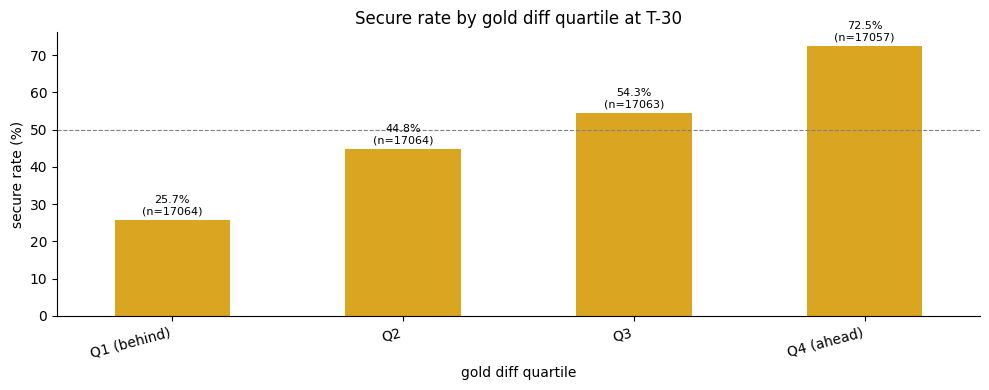

In [9]:
# Bin gold_diff_T_30 into quartiles
df['gold_diff_bin'] = pd.qcut(df['gold_diff_T_30'], q=4,
                               labels=['Q1 (behind)', 'Q2', 'Q3', 'Q4 (ahead)'])
gold_secure = df.groupby('gold_diff_bin', observed=True)['secured'].agg(['mean', 'count'])
gold_secure.columns = ['secure_rate', 'n']

ax = (gold_secure['secure_rate'] * 100).plot(kind='bar', color='goldenrod')
ax.set_title('Secure rate by gold diff quartile at T-30')
ax.set_xlabel('gold diff quartile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=15, ha='right')
for i, (rate, n) in enumerate(zip(gold_secure['secure_rate'] * 100, gold_secure['n'])):
    ax.annotate(f'{rate:.1f}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Feature correlation with `secured`

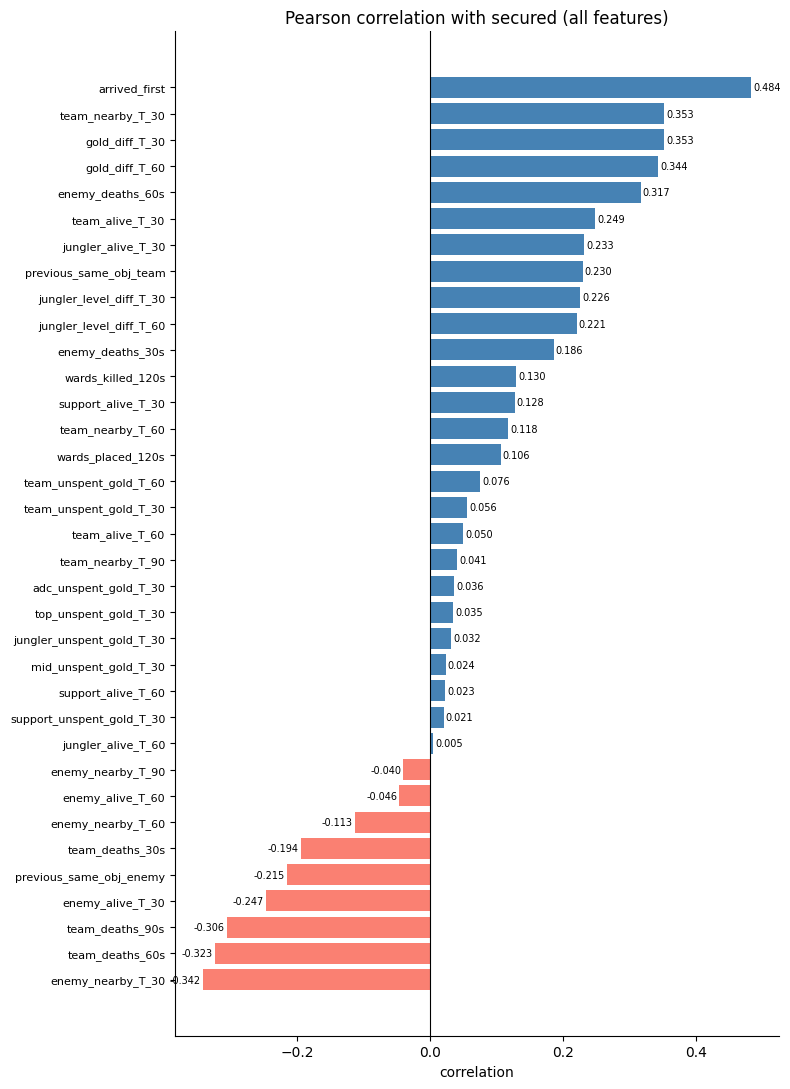

enemy_nearby_T_30           -0.342
team_deaths_60s             -0.323
team_deaths_90s             -0.306
enemy_alive_T_30            -0.247
previous_same_obj_enemy     -0.215
team_deaths_30s             -0.194
enemy_nearby_T_60           -0.113
enemy_alive_T_60            -0.046
enemy_nearby_T_90           -0.040
jungler_alive_T_60           0.005
support_unspent_gold_T_30    0.021
support_alive_T_60           0.023
mid_unspent_gold_T_30        0.024
jungler_unspent_gold_T_30    0.032
top_unspent_gold_T_30        0.035
adc_unspent_gold_T_30        0.036
team_nearby_T_90             0.041
team_alive_T_60              0.050
team_unspent_gold_T_30       0.056
team_unspent_gold_T_60       0.076
wards_placed_120s            0.106
team_nearby_T_60             0.118
support_alive_T_30           0.128
wards_killed_120s            0.130
enemy_deaths_30s             0.186
jungler_level_diff_T_60      0.221
jungler_level_diff_T_30      0.226
previous_same_obj_team       0.230
jungler_alive_T_30  

In [10]:
numeric_features = [
    # Arrival / presence
    'arrived_first',
    'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30',
    'enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30',
    # Alive counts
    'team_alive_T_30', 'team_alive_T_60',
    'enemy_alive_T_30', 'enemy_alive_T_60',
    'jungler_alive_T_30', 'jungler_alive_T_60',
    'support_alive_T_30', 'support_alive_T_60',
    # Deaths
    'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s',
    'enemy_deaths_30s', 'enemy_deaths_60s',
    # Gold / combat power
    'gold_diff_T_30', 'gold_diff_T_60',
    'jungler_level_diff_T_30', 'jungler_level_diff_T_60',
    # Vision
    'wards_placed_120s', 'wards_killed_120s',
    # Prior context
    'previous_same_obj_team', 'previous_same_obj_enemy',
    # Unspent gold
    'team_unspent_gold_T_30', 'team_unspent_gold_T_60',
    'jungler_unspent_gold_T_30', 'support_unspent_gold_T_30',
    'adc_unspent_gold_T_30', 'mid_unspent_gold_T_30', 'top_unspent_gold_T_30',
]

corr = df[numeric_features + ['secured']].corr()['secured'].drop('secured').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in corr]
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(range(len(corr)), corr.values, color=colors)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title('Pearson correlation with secured (all features)')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('correlation')
for i, val in enumerate(corr.values):
    ax.annotate(f'{val:.3f}', (val + (0.003 if val >= 0 else -0.003), i),
                va='center', ha='left' if val >= 0 else 'right', fontsize=7)
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

## 7b. Feature-feature correlation heatmap

Shows how all numeric features correlate with each other and with `secured`. Useful for spotting redundant features and natural clusters (e.g. T_30 vs T_60 versions of the same stat).

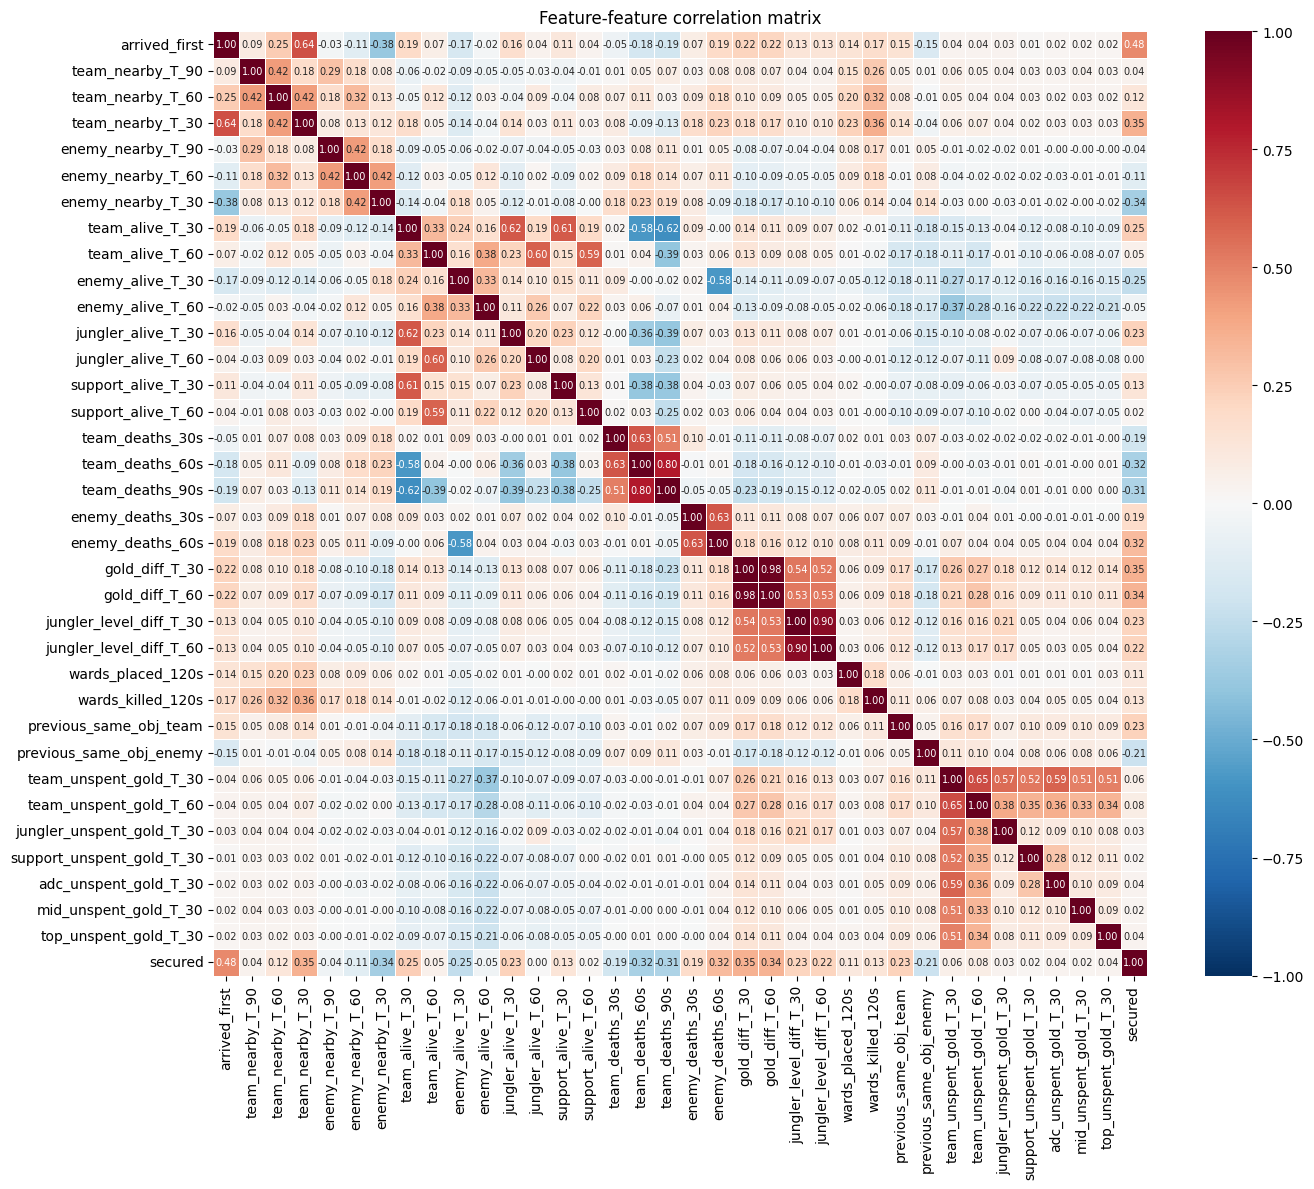

In [11]:
try:
    import seaborn as sns
    has_seaborn = True
except ImportError:
    has_seaborn = False
    print('seaborn not installed — falling back to matplotlib. pip install seaborn for a nicer heatmap.')

heatmap_features = numeric_features + ['secured']
corr_matrix = df[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))

if has_seaborn:
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.4, ax=ax,
    )
else:
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(heatmap_features)))
    ax.set_yticks(range(len(heatmap_features)))
    ax.set_xticklabels(heatmap_features, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(heatmap_features, fontsize=7)
    for i in range(len(heatmap_features)):
        for j in range(len(heatmap_features)):
            ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}',
                    ha='center', va='center', fontsize=5.5)

ax.set_title('Feature-feature correlation matrix', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Dragon 1 vs Dragon 2 — outcome composition

> **Note on secure rates**: across all rows the aggregate secure rate is always ~50% by construction — for every objective one team secures it, the other doesn't. Comparing objective types by secure rate is therefore uninformative. The interesting comparison is *how* objectives are contested: clean takes, throw-setups, coinflips, etc.

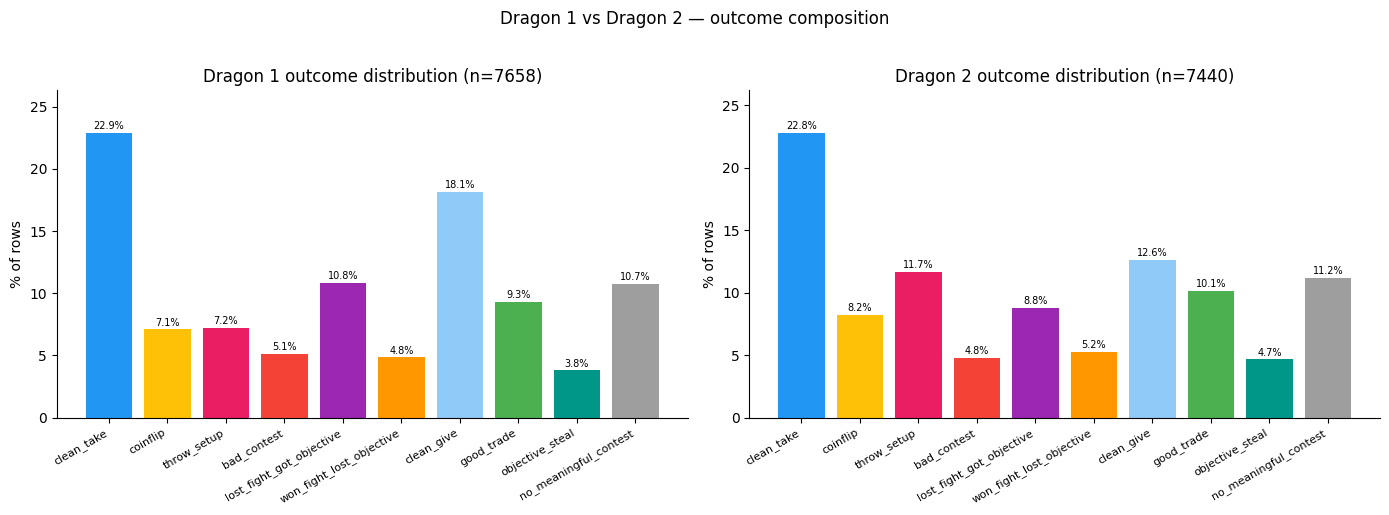

Metric                                Dragon 1   Dragon 2
---------------------------------------------------------
arrived_first %                          38.52      37.15
avg deaths in T-60s                       0.89       1.13
avg deaths in T-30s                       0.35       0.48
throw_setup rate %                        7.21      11.65
bad_contest rate %                        5.13       4.77
clean_take rate %                        22.89      22.77
coinflip rate %                           7.10       8.20
no_meaningful_contest %                  10.73      11.18
avg jungler alive T-30                    0.95       0.90
avg support alive T-30                    0.93       0.88


In [12]:
dragons = df[df['objective_type'] == 'DRAGON']

# Outcome composition stacked bars
OUTCOME_COLORS = {
    'clean_take':                '#2196F3',
    'clean_give':                '#90CAF9',
    'good_trade':                '#4CAF50',
    'coinflip':                  '#FFC107',
    'bad_contest':               '#F44336',
    'won_fight_lost_objective':  '#FF9800',
    'lost_fight_got_objective':  '#9C27B0',
    'throw_setup':               '#E91E63',
    'objective_steal':           '#009688',
    'no_meaningful_contest':     '#9E9E9E',
}

labels_to_show = [
    'clean_take', 'coinflip', 'throw_setup', 'bad_contest',
    'lost_fight_got_objective', 'won_fight_lost_objective',
    'clean_give', 'good_trade', 'objective_steal', 'no_meaningful_contest',
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dragon_num in zip(axes, [1, 2]):
    sub = dragons[dragons['objective_number'] == dragon_num]
    comp = sub['outcome_label'].value_counts(normalize=True) * 100
    comp = comp.reindex(labels_to_show).fillna(0)
    ax.bar(comp.index, comp.values,
           color=[OUTCOME_COLORS.get(l, '#ccc') for l in comp.index])
    ax.set_title(f'Dragon {dragon_num} outcome distribution (n={len(sub)})')
    ax.set_ylabel('% of rows')
    ax.set_ylim(0, comp.max() * 1.15)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    for i, (lbl, val) in enumerate(zip(comp.index, comp.values)):
        if val > 1:
            ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=7)

plt.suptitle('Dragon 1 vs Dragon 2 — outcome composition', y=1.02)
plt.tight_layout()
plt.show()

# Summary stats that ARE meaningful (not secure rate)
print(f'{"Metric":<35} {"Dragon 1":>10} {"Dragon 2":>10}')
print('-' * 57)
for num in [1, 2]:
    sub = dragons[dragons['objective_number'] == num]
for metric, col, fn in [
    ('arrived_first %',            'arrived_first',          lambda s: s.mean() * 100),
    ('avg deaths in T-60s',        'team_deaths_60s',        lambda s: s.mean()),
    ('avg deaths in T-30s',        'team_deaths_30s',        lambda s: s.mean()),
    ('throw_setup rate %',         'outcome_label',          lambda s: (s=='throw_setup').mean()*100),
    ('bad_contest rate %',         'outcome_label',          lambda s: (s=='bad_contest').mean()*100),
    ('clean_take rate %',          'outcome_label',          lambda s: (s=='clean_take').mean()*100),
    ('coinflip rate %',            'outcome_label',          lambda s: (s=='coinflip').mean()*100),
    ('no_meaningful_contest %',    'outcome_label',          lambda s: (s=='no_meaningful_contest').mean()*100),
    ('avg jungler alive T-30',     'jungler_alive_T_30',     lambda s: s.mean()),
    ('avg support alive T-30',     'support_alive_T_30',     lambda s: s.mean()),
]:
    d1 = fn(dragons[dragons['objective_number'] == 1][col])
    d2 = fn(dragons[dragons['objective_number'] == 2][col])
    print(f'{metric:<35} {d1:>10.2f} {d2:>10.2f}')

## 8b. Dragon 3, 4, 5+ comparison

Later dragons are higher stakes — dragon 4 awards soul, dragon 5+ can be soul/elder chasing. Expect throw_setup and bad_contest rates to rise as teams are more willing to force fights.

            n_rows  clean_take_%  coinflip_%  throw_%  bad_contest_%  no_contest_%  avg_deaths_30s  avg_deaths_60s  arrived_first_%
dragon_num                                                                                                                         
1             7658          22.9         7.1      7.2            5.1          10.7            0.35            0.89             38.5
2             7440          22.8         8.2     11.7            4.8          11.2            0.48            1.13             37.2
3             6732          23.8         6.2     12.3            3.4          17.2            0.55            1.24             35.3
4             5198          23.4         4.5     11.9            3.0          23.5            0.58            1.29             33.8
5             2246          22.7         3.8     12.0            2.5          26.4            0.59            1.24             32.3
6              618          21.2         3.1     11.8            2.8        

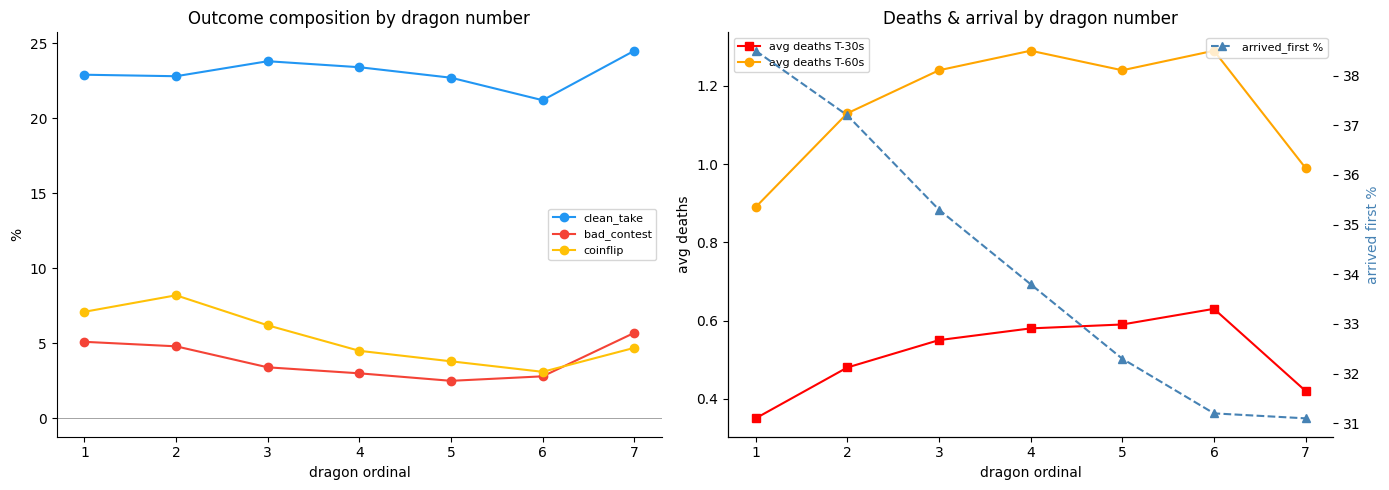

In [13]:
dragons_all = df[df['objective_type'] == 'DRAGON'].copy()
dragon_nums = sorted(dragons_all['objective_number'].unique())

summary = []
for num in dragon_nums:
    sub = dragons_all[dragons_all['objective_number'] == num]
    summary.append({
        'dragon_num': num,
        'n_rows': len(sub),
        'clean_take_%': round((sub['outcome_label'] == 'clean_take').mean() * 100, 1),
        'coinflip_%':   round((sub['outcome_label'] == 'coinflip').mean() * 100, 1),
        'throw_%':      round((sub['outcome_label'] == 'throw_setup').mean() * 100, 1),
        'bad_contest_%':round((sub['outcome_label'] == 'bad_contest').mean() * 100, 1),
        'no_contest_%': round((sub['outcome_label'] == 'no_meaningful_contest').mean() * 100, 1),
        'avg_deaths_30s':   round(sub['team_deaths_30s'].mean(), 2),
        'avg_deaths_60s':   round(sub['team_deaths_60s'].mean(), 2),
        'arrived_first_%':  round(sub['arrived_first'].mean() * 100, 1),
    })

summary_df = pd.DataFrame(summary).set_index('dragon_num')
print(summary_df.to_string())

# Outcome composition progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

key_outcomes = ['clean_take', 'throw_setup', 'bad_contest', 'coinflip', 'no_meaningful_contest']
colors_map = {'clean_take': '#2196F3', 'throw_setup': '#E91E63',
              'bad_contest': '#F44336', 'coinflip': '#FFC107', 'no_meaningful_contest': '#9E9E9E'}

ax = axes[0]
for outcome in key_outcomes:
    col = f'{outcome}_%'
    if col in summary_df.columns:
        ax.plot(summary_df.index, summary_df[col], marker='o', label=outcome,
                color=colors_map.get(outcome))
ax.set_title('Outcome composition by dragon number')
ax.set_xlabel('dragon ordinal')
ax.set_ylabel('%')
ax.set_xticks(dragon_nums)
ax.legend(fontsize=8)
ax.axhline(0, color='gray', linewidth=0.5)

# Deaths & arrival progression
ax = axes[1]
ax.plot(summary_df.index, summary_df['avg_deaths_30s'], marker='s', color='red', label='avg deaths T-30s')
ax.plot(summary_df.index, summary_df['avg_deaths_60s'], marker='o', color='orange', label='avg deaths T-60s')
ax2 = ax.twinx()
ax2.plot(summary_df.index, summary_df['arrived_first_%'], marker='^', color='steelblue',
         linestyle='--', label='arrived_first %')
ax2.set_ylabel('arrived first %', color='steelblue')
ax.set_title('Deaths & arrival by dragon number')
ax.set_xlabel('dragon ordinal')
ax.set_ylabel('avg deaths')
ax.set_xticks(dragon_nums)
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 9. Grubs, Herald, and Baron

- **Voidgrubs (HORDE)**: 6 grubs total, first camp spawns ~5 min. Ordinals 1-3 = first camp, 4-6 = second camp. Most games only see the first camp fully taken.
- **Riftherald (RIFTHERALD)**: Spawns ~8 min, only one per game before Baron replaces it. High-value tempo tool.
- **Baron Nashor (BARON_NASHOR)**: Spawns at 20 min, major power spike. Later barons are riskier to contest.

Note: outcome labels (clean_take, coinflip, etc.) apply to all objective types, but the thresholds in the classifier were tuned for dragon. Results for other objectives may show edge cases.

                     n  clean_take_%  coinflip_%  throw_%  bad_contest_%  no_contest_%  avg_jg_alive_T30  avg_deaths_30s  avg_deaths_60s  arrived_first_%
objective                                                                                                                                                
Voidgrubs (1-3)  22948          18.1         4.9      6.1            3.0          27.0              0.96            0.41            0.90             31.0
Voidgrubs (4-6)    198          18.2         3.0      8.1            2.5          19.2              0.95            0.39            0.92             37.9
Riftherald        7164          20.2         4.3      7.1            2.5          19.9              0.88            0.46            1.08             35.3
Baron 1           5690          26.2         2.9      8.2            2.8          22.6              0.75            0.37            1.27             36.1
Baron 2           1908          23.3         2.0      6.9            2.5    

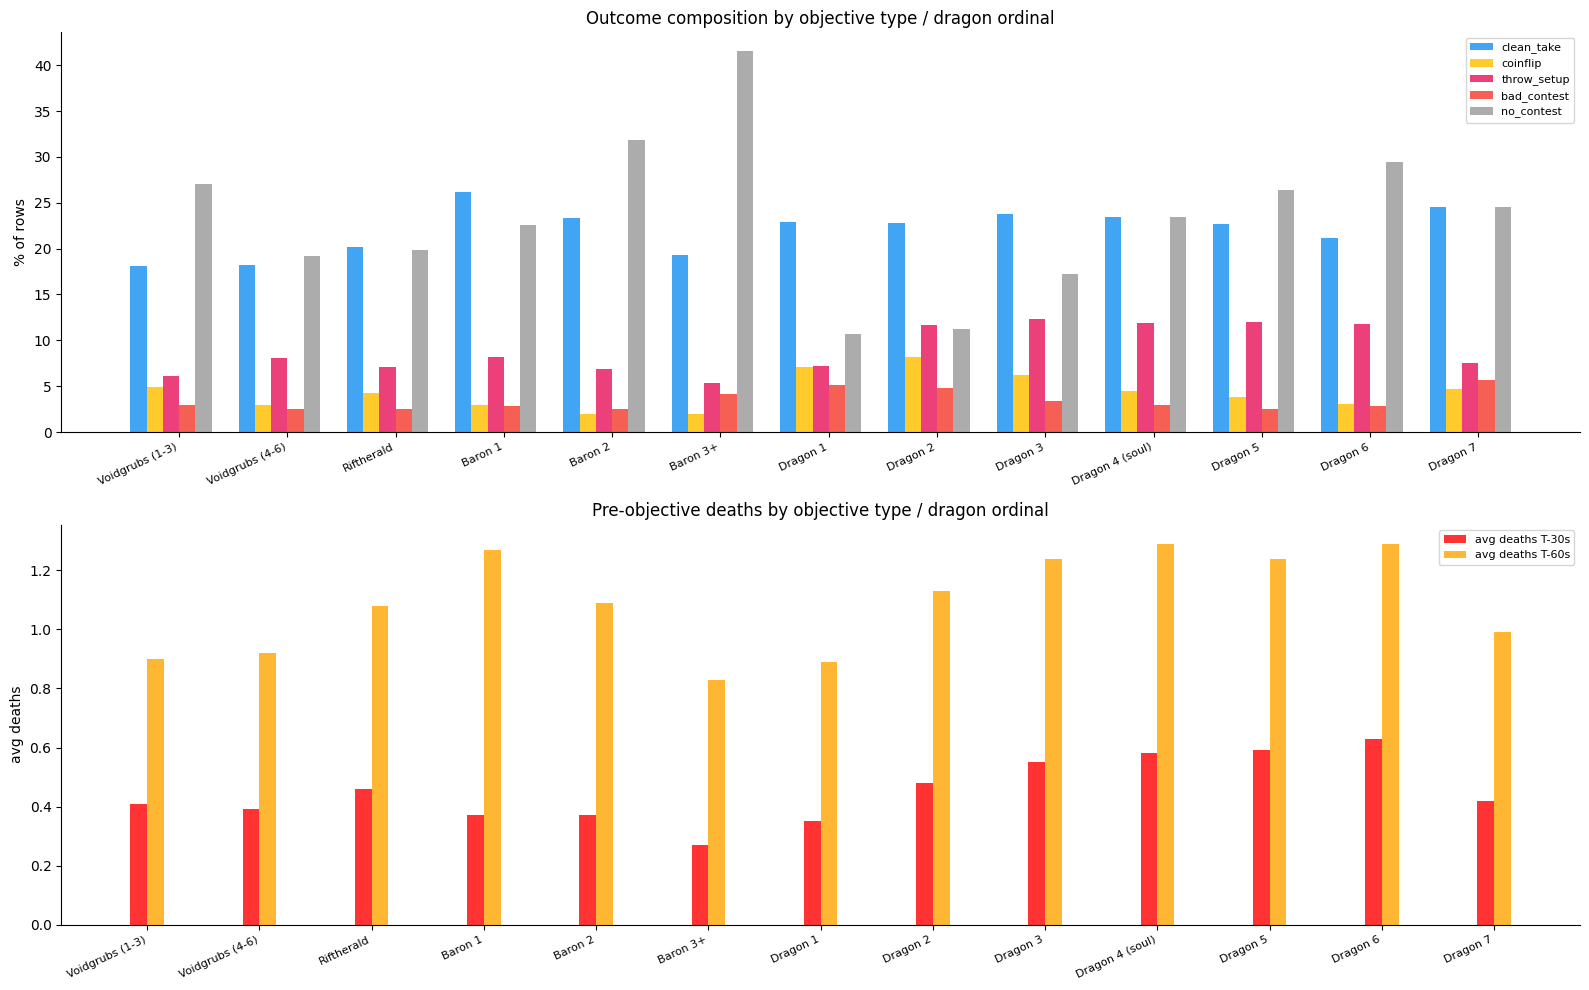

In [14]:
obj_groups = {}

# Voidgrubs, Herald, Baron
obj_groups['Voidgrubs (1-3)'] = df[(df['objective_type'] == 'HORDE') & (df['objective_number'] <= 3)]
obj_groups['Voidgrubs (4-6)'] = df[(df['objective_type'] == 'HORDE') & (df['objective_number'] >= 4)]
obj_groups['Riftherald']      = df[df['objective_type'] == 'RIFTHERALD']
obj_groups['Baron 1']         = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] == 1)]
obj_groups['Baron 2']         = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] == 2)]
obj_groups['Baron 3+']        = df[(df['objective_type'] == 'BARON_NASHOR') & (df['objective_number'] >= 3)]

# Dragons by ordinal 1-7 (each ordinal = a distinct game-state; not all games reach each number)
dragon_ordinal_labels = {1: 'Dragon 1', 2: 'Dragon 2', 3: 'Dragon 3',
                          4: 'Dragon 4 (soul)', 5: 'Dragon 5', 6: 'Dragon 6', 7: 'Dragon 7'}
for ordinal, label in dragon_ordinal_labels.items():
    sub = df[(df['objective_type'] == 'DRAGON') & (df['objective_number'] == ordinal)]
    if len(sub) >= 50:
        obj_groups[label] = sub

rows = []
for label, sub in obj_groups.items():
    if len(sub) == 0:
        continue
    rows.append({
        'objective': label,
        'n': len(sub),
        'clean_take_%':   round((sub['outcome_label'] == 'clean_take').mean() * 100, 1),
        'coinflip_%':     round((sub['outcome_label'] == 'coinflip').mean() * 100, 1),
        'throw_%':        round((sub['outcome_label'] == 'throw_setup').mean() * 100, 1),
        'bad_contest_%':  round((sub['outcome_label'] == 'bad_contest').mean() * 100, 1),
        'no_contest_%':   round((sub['outcome_label'] == 'no_meaningful_contest').mean() * 100, 1),
        'avg_jg_alive_T30':  round(sub['jungler_alive_T_30'].mean(), 2),
        'avg_deaths_30s':    round(sub['team_deaths_30s'].mean(), 2),
        'avg_deaths_60s':    round(sub['team_deaths_60s'].mean(), 2),
        'arrived_first_%':   round(sub['arrived_first'].mean() * 100, 1),
    })

comparison = pd.DataFrame(rows).set_index('objective')
print(comparison.to_string())

# Outcome composition grouped bar chart
x = range(len(comparison))
width = 0.15
outcomes_to_plot = ['clean_take_%', 'coinflip_%', 'throw_%', 'bad_contest_%', 'no_contest_%']
outcome_labels_short = ['clean_take', 'coinflip', 'throw_setup', 'bad_contest', 'no_contest']
palette = ['#2196F3', '#FFC107', '#E91E63', '#F44336', '#9E9E9E']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
for i, (col, lbl, color) in enumerate(zip(outcomes_to_plot, outcome_labels_short, palette)):
    offset = (i - len(outcomes_to_plot) / 2) * width
    ax.bar([xi + offset for xi in x], comparison[col], width, label=lbl, color=color, alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=25, ha='right', fontsize=8)
ax.set_title('Outcome composition by objective type / dragon ordinal')
ax.set_ylabel('% of rows')
ax.legend(fontsize=8)

# Deaths & arrival
ax = axes[1]
ax.bar([xi - width/2 for xi in x], comparison['avg_deaths_30s'], width, label='avg deaths T-30s', color='red', alpha=0.8)
ax.bar([xi + width/2 for xi in x], comparison['avg_deaths_60s'], width, label='avg deaths T-60s', color='orange', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(comparison.index, rotation=25, ha='right', fontsize=8)
ax.set_title('Pre-objective deaths by objective type / dragon ordinal')
ax.set_ylabel('avg deaths')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Rank breakdown

Rank distribution:
rank_bucket
mid        20856
high       17524
low        16892
elite      12244
unknown      732

98.9% of rows have known rank


C:\Users\Laser\AppData\Local\Temp\ipykernel_56792\3373700560.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ct_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
C:\Users\Laser\AppData\Local\Temp\ipykernel_56792\3373700560.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  throw_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
C:\Users\Laser\AppData\Lo

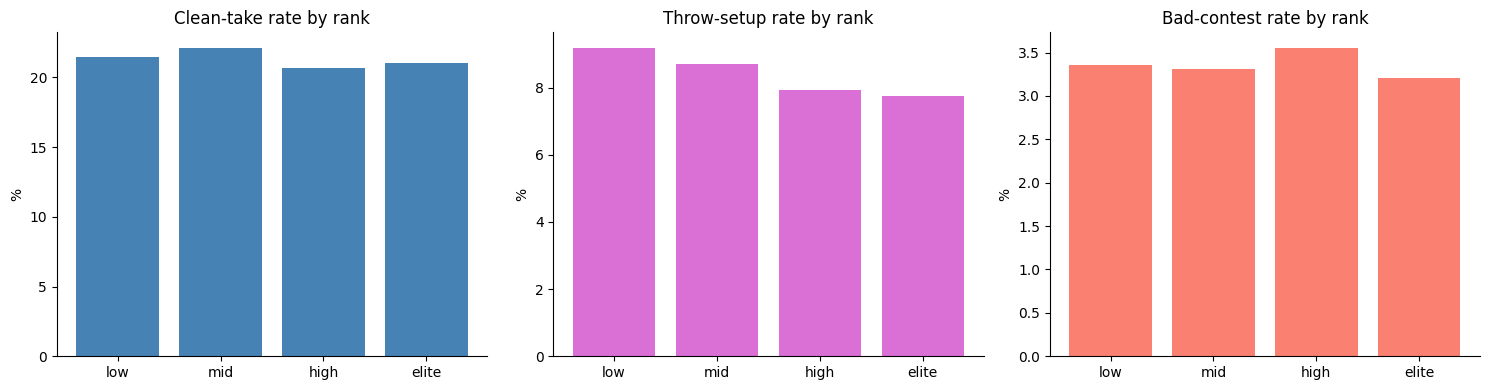


Outcome composition by rank (% of rows):
outcome_label  clean_take  clean_give  good_trade  coinflip  bad_contest  won_fight_lost_objective  lost_fight_got_objective  throw_setup  objective_steal  no_meaningful_contest
rank_bucket                                                                                                                                                                      
low                  21.4        15.3         8.5       5.4          3.4                       4.1                       8.7          9.2              4.1                   19.8
mid                  22.1        15.8         8.2       5.0          3.3                       4.0                       8.3          8.7              4.0                   20.6
high                 20.6        15.0         8.8       5.4          3.6                       3.9                       8.5          7.9              4.1                   22.2
elite                21.0        15.5         8.8       5.1         

In [15]:
rank_counts = df['rank_bucket'].value_counts()
print('Rank distribution:')
print(rank_counts.to_string())
print(f"\n{100 * (df['rank_bucket'] != 'unknown').mean():.1f}% of rows have known rank")

rank_order = ['low', 'mid', 'high', 'elite']
ranks_present = [r for r in rank_order if r in df['rank_bucket'].values]

if ranks_present:
    # Outcome composition by rank — meaningful; aggregate secure rate is always ~50%
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # clean_take rate by rank (how often did the team set up cleanly?)
    ct_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'clean_take').mean() * 100
    )
    axes[0].bar(rank_order, [ct_rate.get(r, 0) for r in rank_order], color='steelblue')
    axes[0].set_title('Clean-take rate by rank')
    axes[0].set_ylabel('%')

    # Throw setup rate by rank
    throw_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'throw_setup').mean() * 100
    )
    axes[1].bar(rank_order, [throw_rate.get(r, 0) for r in rank_order], color='orchid')
    axes[1].set_title('Throw-setup rate by rank')
    axes[1].set_ylabel('%')

    # Bad contest rate by rank
    bad_rate = df[df['rank_bucket'].isin(ranks_present)].groupby('rank_bucket').apply(
        lambda x: (x['outcome_label'] == 'bad_contest').mean() * 100
    )
    axes[2].bar(rank_order, [bad_rate.get(r, 0) for r in rank_order], color='salmon')
    axes[2].set_title('Bad-contest rate by rank')
    axes[2].set_ylabel('%')

    plt.tight_layout()
    plt.show()

    # Full outcome composition stacked by rank
    print('\nOutcome composition by rank (% of rows):')
    rank_comp = pd.crosstab(
        df[df['rank_bucket'].isin(ranks_present)]['rank_bucket'],
        df[df['rank_bucket'].isin(ranks_present)]['outcome_label'],
        normalize='index',
    ) * 100
    rank_comp = rank_comp.reindex(index=ranks_present, columns=OUTCOME_ORDER).fillna(0).round(1)
    print(rank_comp.to_string())

## 10. Full baseline report (text)

## 12. Unspent gold at T-30 and T-60

`current_gold` is gold the player is currently holding but hasn't spent. High unspent gold at T-30 means the player hasn't been able to back and buy items — a proxy for being "power-spiked" or "behind on items relative to their income."

**Questions:**
- Do losing teams tend to have more unspent gold (didn't get to back before objective)?
- Which roles show the biggest unspent gold difference between securing and non-securing teams?
- Does team-total unspent gold predict outcome better than individual role gold?

Role            Secured mean  Not secured mean     Diff
-------------------------------------------------------
team_unspent_gold_T_30                    3309        3158      +151
jungler_unspent_gold_T_30                  777         739       +38
support_unspent_gold_T_30                  514         498       +16
adc_unspent_gold_T_30                      709         670       +40
mid_unspent_gold_T_30                      652         629       +23
top_unspent_gold_T_30                      657         621       +35

Correlation of unspent gold with secured:
support_unspent_gold_T_30    0.021
mid_unspent_gold_T_30        0.024
support_unspent_gold_T_60    0.026
mid_unspent_gold_T_60        0.031
jungler_unspent_gold_T_30    0.032
top_unspent_gold_T_30        0.035
top_unspent_gold_T_60        0.036
adc_unspent_gold_T_30        0.036
adc_unspent_gold_T_60        0.038
team_unspent_gold_T_30       0.056
jungler_unspent_gold_T_60    0.067
team_unspent_gold_T_60       0.076


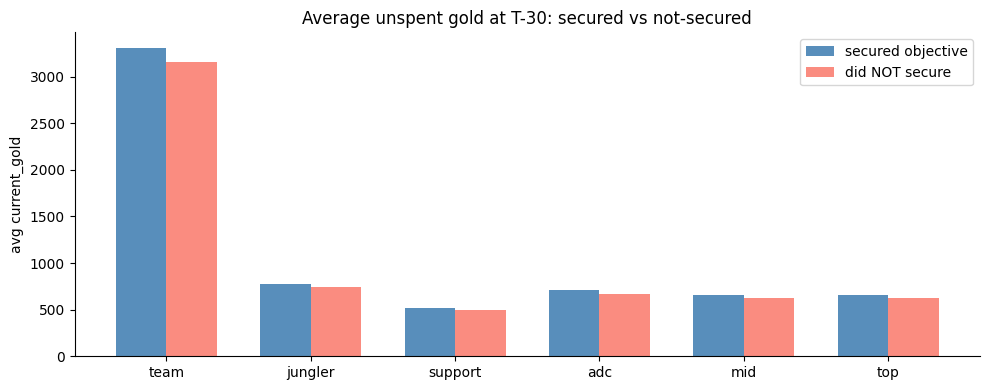

C:\Users\Laser\AppData\Local\Temp\ipykernel_56792\15341549.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_outcome, labels=order_by_median, showfliers=False)


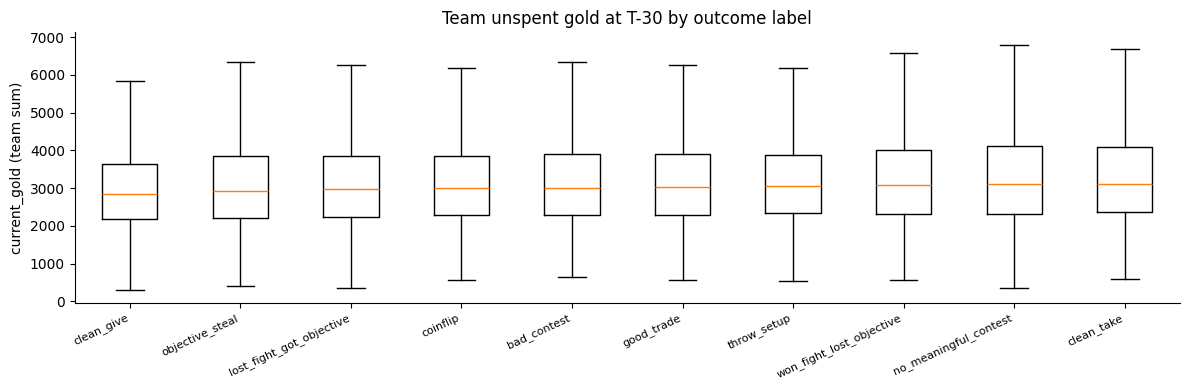

In [17]:
gold_roles = ['team', 'jungler', 'support', 'adc', 'mid', 'top']

# Avg unspent gold at T-30 by secured outcome
print(f'{"Role":<12}  {"Secured mean":>14} {"Not secured mean":>17} {"Diff":>8}')
print('-' * 55)
for role in gold_roles:
    col = f'{role}_unspent_gold_T_30'
    if col not in df.columns:
        continue
    secured_mean   = df[df['secured'] == 1][col].mean()
    unsecured_mean = df[df['secured'] == 0][col].mean()
    diff = secured_mean - unsecured_mean
    print(f'{col:<36}  {secured_mean:>8.0f}  {unsecured_mean:>10.0f}  {diff:>+8.0f}')

# Correlation with secured
print('\nCorrelation of unspent gold with secured:')
gold_cols = [f'{r}_unspent_gold_T_30' for r in gold_roles if f'{r}_unspent_gold_T_30' in df.columns]
gold_cols += [f'{r}_unspent_gold_T_60' for r in gold_roles if f'{r}_unspent_gold_T_60' in df.columns]
corrs = df[gold_cols + ['secured']].corr()['secured'].drop('secured').sort_values()
print(corrs.round(3).to_string())

# Chart: avg unspent gold at T-30 by secured=0 vs secured=1
fig, ax = plt.subplots(figsize=(10, 4))
role_cols_t30 = [f'{r}_unspent_gold_T_30' for r in gold_roles if f'{r}_unspent_gold_T_30' in df.columns]
x = range(len(role_cols_t30))
w = 0.35
means_secured    = [df[df['secured']==1][c].mean() for c in role_cols_t30]
means_unsecured  = [df[df['secured']==0][c].mean() for c in role_cols_t30]
ax.bar([xi - w/2 for xi in x], means_secured,   w, label='secured objective',  color='steelblue', alpha=0.9)
ax.bar([xi + w/2 for xi in x], means_unsecured, w, label='did NOT secure',     color='salmon',    alpha=0.9)
ax.set_xticks(list(x))
ax.set_xticklabels([c.replace('_unspent_gold_T_30', '') for c in role_cols_t30])
ax.set_title('Average unspent gold at T-30: secured vs not-secured')
ax.set_ylabel('avg current_gold')
ax.legend()
plt.tight_layout()
plt.show()

# Boxplot: team unspent gold by outcome label
fig, ax = plt.subplots(figsize=(12, 4))
order_by_median = (
    df.groupby('outcome_label')['team_unspent_gold_T_30']
    .median().sort_values().index.tolist()
)
data_by_outcome = [df[df['outcome_label'] == lbl]['team_unspent_gold_T_30'].dropna().values
                   for lbl in order_by_median]
ax.boxplot(data_by_outcome, labels=order_by_median, showfliers=False)
ax.set_title('Team unspent gold at T-30 by outcome label')
ax.set_ylabel('current_gold (team sum)')
plt.xticks(rotation=25, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [18]:
from lolobj.analysis.baseline_report import run_report
run_report(parquet_path)


Loaded 68248 rows from C:\Users\Laser\dig-baron\data\processed\objective_windows.parquet
Columns: ['match_id', 'objective_instance', 'objective_type', 'objective_number', 'objective_time_ms', 'team_id', 'team_side', 'rank_bucket', 'patch', 'monster_subtype', 'team_alive_T_30', 'team_alive_T_60', 'enemy_alive_T_30', 'enemy_alive_T_60', 'jungler_alive_T_30', 'jungler_alive_T_60', 'support_alive_T_30', 'support_alive_T_60', 'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s', 'enemy_deaths_30s', 'enemy_deaths_60s', 'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30', 'enemy_nearby_T_90', 'enemy_nearby_T_60', 'enemy_nearby_T_30', 'jungler_dist_T_30', 'jungler_dist_T_60', 'support_dist_T_30', 'support_dist_T_60', 'mid_dist_T_30', 'mid_dist_T_60', 'arrived_first', 'gold_diff_T_30', 'gold_diff_T_60', 'jungler_level_diff_T_30', 'jungler_level_diff_T_60', 'wards_placed_120s', 'wards_killed_120s', 'previous_same_obj_team', 'previous_same_obj_enemy', 'jungler_unspent_gold_T_30', 'jung